In [1]:
import sccellfie
import scanpy as sc

/Users/christoffer/miniconda3/envs/sccellfie_env/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/christoffer/miniconda3/envs/sccellfie_env/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/christoffer/miniconda3/envs/sccellfie_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instea

In [2]:
adata = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_annotation_with_rbd_2.h5ad')

In [58]:
adata

AnnData object with n_obs × n_vars = 980474 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'n_genes_by_counts', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_2', 'cell_class', 'sample_id', 'age', 'sex', 'genotype', 'condition', 'cell_type', 'cell_id', 'rbd_domain_0.1', 'rbd_domain_0.2', 'rbd_domain_0.5', 'rbd_domain_1.0', 'RBD_compartment', 'RBD_compartment_simplified', 'leiden_1.5', 'leiden_2.1', 'leiden_2.3', 'leiden_2.5', 'leiden_3', 'age-condition'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'normalization', 'neighbors'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

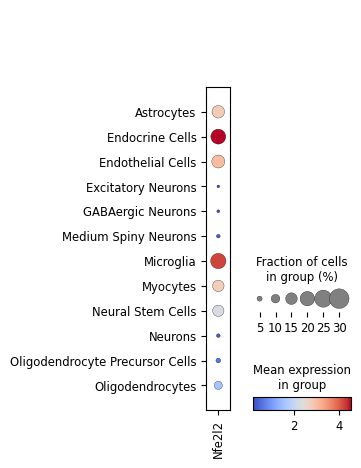

In [60]:
sc.pl.dotplot(
    adata,
    var_names=['Nfe2l2'],
    groupby="cell_class",
    color_map="coolwarm",
)

In [66]:
import sys
sys.path.append("/Users/christoffer/work/karolinska/development/oligo-mtDSB")  # repo root
from utils.spatial_utils import plot_spatial_compact_fast
import importlib
from utils import spatial_utils
importlib.reload(spatial_utils)


<module 'utils.spatial_utils' from '/Users/christoffer/work/karolinska/development/oligo-mtDSB/utils/spatial_utils.py'>

In [71]:
x = adata[:, "Nfe2l2"].X
print(type(x))
print(getattr(x, "dtype", None))
print(hasattr(x, "toarray"))

<class 'anndata._core.views.SparseCSRMatrixView'>
float32
True


In [70]:
# usage
spatial_utils.plot_spatial_compact_fast(
    adata,
    color="Nfe2l2",
    groupby="sample_id",
    spot_size=1,
    cols=6,
    height=8,
)

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

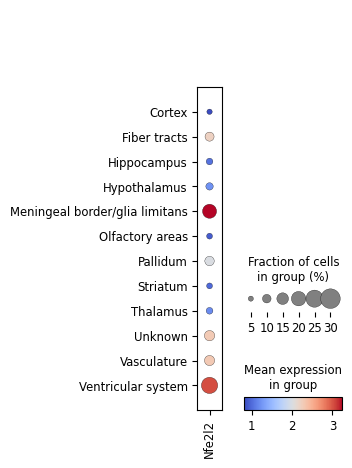

In [59]:
sc.pl.dotplot(
    adata,
    var_names=['Nfe2l2'],
    groupby="RBD_compartment_simplified",
    color_map="coolwarm",
)

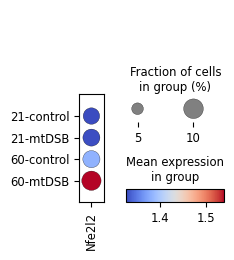

In [55]:
sc.pl.dotplot(
    adata,
    var_names=['Nfe2l2'],
    groupby="age-condition",
    color_map="coolwarm",
)

In [3]:
adata.X = adata.layers['counts'].copy()

In [4]:
adata.obs['n_counts']

aaaaakjg-1     631.0
aaaaikjn-1    1102.0
aaaapoln-1     335.0
aaacmkgf-1    1931.0
aaaefdnf-1    1105.0
               ...  
oifndkbo-1     419.0
oifolalk-1     219.0
oifphdni-1      76.0
oigabhlk-1     176.0
oigafpoe-1      70.0
Name: n_counts, Length: 980474, dtype: float32

In [5]:

# Run one-command scCellFie pipeline
results = sccellfie.run_sccellfie_pipeline(adata,
                                           organism='mouse',
                                           sccellfie_data_folder=None,
                                           n_counts_col='n_counts',
                                           process_by_group=False,
                                           groupby=None,
                                           neighbors_key='neighbors',
                                           n_neighbors=10,
                                           batch_key='sample_id',
                                           threshold_key='sccellfie_threshold',
                                           smooth_cells=True,
                                           alpha=0.33,
                                           chunk_size=5000,
                                           disable_pbar=False,
                                           save_folder=None,
                                           save_filename=None
                                          )


==== scCellFie Pipeline: Initializing ====
Loading scCellFie database for organism: mouse

==== scCellFie Pipeline: Processing entire dataset ====

---- scCellFie Step: Preprocessing data ----


/Users/christoffer/miniconda3/envs/sccellfie_env/lib/python3.10/site-packages/sccellfie/preprocessing/adata_utils.py:151: UserWarning: Normalizing data.
  warnings.warn("Normalizing data.", UserWarning)



---- scCellFie Step: Computing neighbors ----


/Users/christoffer/miniconda3/envs/sccellfie_env/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)
/Users/christoffer/miniconda3/envs/sccellfie_env/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: divide by zero encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/Users/christoffer/miniconda3/envs/sccellfie_env/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: overflow encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/Users/christoffer/miniconda3/envs/sccellfie_env/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: invalid value encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/Users/christoffer/miniconda3/envs/sccellfie_env/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:737: RuntimeWarning: divide by zero encountered in matmul
  ma


---- scCellFie Step: Preparing inputs ----
Gene names corrected to match database: 9
Shape of new adata object: (980474, 211)
Number of GPRs: 296
Shape of tasks by genes: (158, 211)
Shape of reactions by genes: (296, 211)
Shape of tasks by reactions: (158, 296)

---- scCellFie Step: Smoothing gene expression ----


Smoothing Expression: 100%|███████████████████| 197/197 [00:21<00:00,  8.96it/s]
/Users/christoffer/miniconda3/envs/sccellfie_env/lib/python3.10/site-packages/sccellfie/expression/smoothing.py:188: ImplicitModificationWarning: Setting element `.layers['smoothed_X']` of view, initializing view as actual.
  adata.layers[key_added] = smoothed_matrix



---- scCellFie Step: Computing gene scores ----

---- scCellFie Step: Computing reaction activity ----


Cell Rxn Activities: 100%|█████████████| 980474/980474 [33:24<00:00, 489.16it/s]



---- scCellFie Step: Computing metabolic task activity ----
Removed 9 metabolic tasks with zeros across all cells.

==== scCellFie Pipeline: Processing completed successfully ====


In [6]:
results['adata'].metabolic_tasks.obs

,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,...,rbd_domain_0.2,rbd_domain_0.5,rbd_domain_1.0,RBD_compartment,RBD_compartment_simplified,leiden_1.5,leiden_2.1,leiden_2.3,leiden_2.5,leiden_3
aaaaakjg-1,67.136543,1092.286377,631,0,0,0,1,0,631.0,37.434533,...,0,0,5,Cortex III,Cortex,21,27,25,27,29
aaaaikjn-1,80.635910,779.488647,1102,0,0,0,2,0,1102.0,90.538285,...,0,0,38,Unknown III,Unknown,3,29,27,32,30
aaaapoln-1,67.554489,1513.168579,335,0,0,0,0,0,335.0,20.817032,...,0,0,4,Cortex II,Cortex,9,14,13,10,10
aaacmkgf-1,70.575630,1138.702881,1931,0,0,0,1,0,1931.0,81.055472,...,0,0,5,Cortex III,Cortex,9,29,27,32,30
aaaefdnf-1,583.425537,1142.197876,1105,0,0,0,1,0,1105.0,68.276252,...,0,0,5,Cortex III,Cortex,17,17,22,17,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oifndkbo-1,2379.717529,4785.681152,419,0,0,0,0,0,419.0,42.221095,...,1,2,0,Hypothalamus,Hypothalamus,4,21,37,42,45
oifolalk-1,2281.881104,4803.725098,219,0,0,0,0,0,219.0,36.170158,...,1,2,0,Hypothalamus,Hypothalamus,19,11,15,19,40
oifphdni-1,2343.403564,4830.252441,76,0,0,0,0,0,76.0,14.946719,...,1,2,0,Hypothalamus,Hypothalamus,4,21,37,38,33
oigabhlk-1,2341.813477,4843.651367,176,0,0,0,0,0,176.0,30.661095,...,1,2,0,Hypothalamus,Hypothalamus,19,11,15,19,40


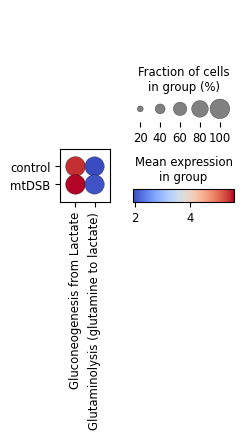

In [7]:
sc.pl.dotplot(
    results['adata'].metabolic_tasks,
    var_names=[i for i in results['adata'].metabolic_tasks.var.index if "lactate" in i.lower()],
    groupby="condition",
    color_map="coolwarm",
)

In [10]:
adata.obs['age-condition'] = adata.obs['age'].astype(str) + '-' + adata.obs['condition'].astype(str)

In [14]:
results['adata'].metabolic_tasks.obs['age-condition'] = results['adata'].metabolic_tasks.obs['age'].astype(str) + '-' + results['adata'].metabolic_tasks.obs['condition'].astype(str)

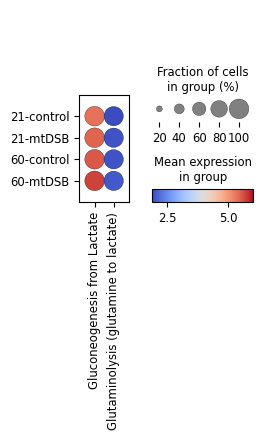

In [17]:
sc.pl.dotplot(
    results['adata'].metabolic_tasks,
    var_names=[i for i in results['adata'].metabolic_tasks.var.index if "lactate" in i.lower()],
    groupby="age-condition",
    color_map="coolwarm",vmax = 6,
)

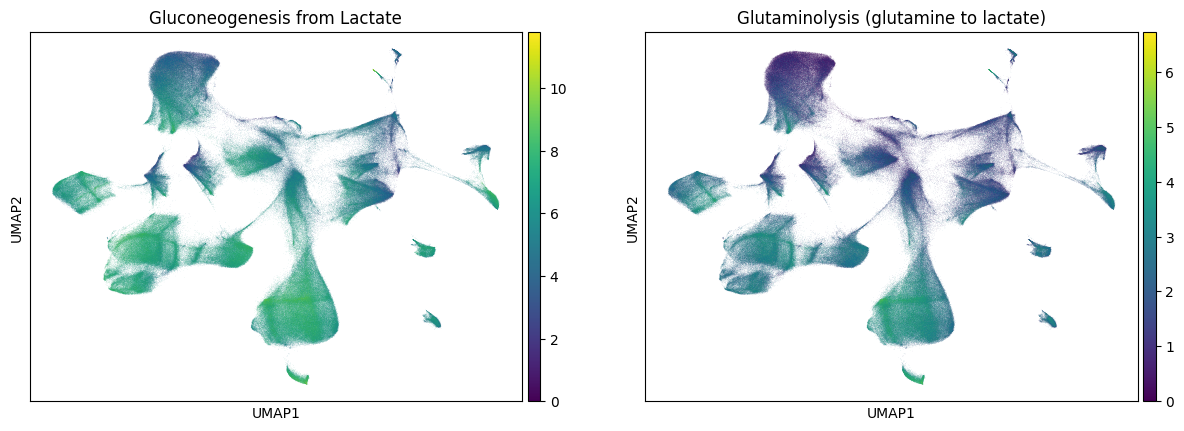

In [18]:
sc.pl.umap(results['adata'].metabolic_tasks, color = [i for i in results['adata'].metabolic_tasks.var.index if "lactate" in i.lower()])

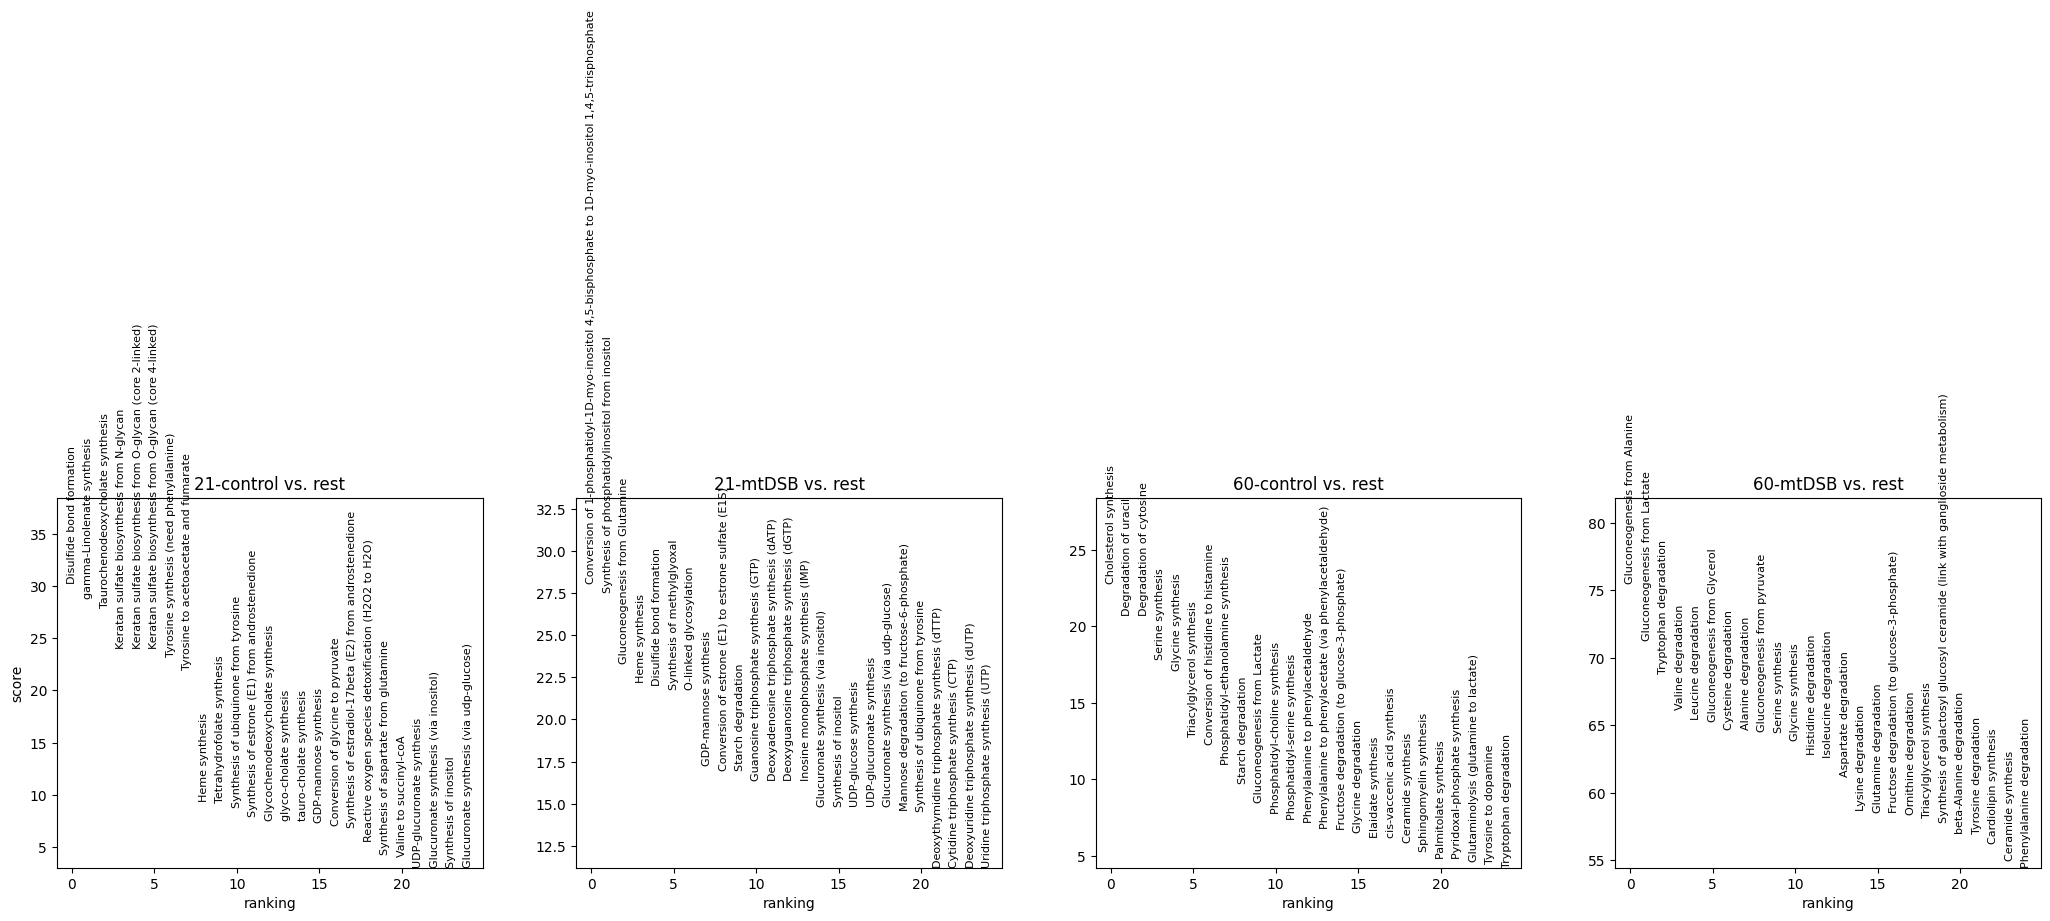

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,21-control,Disulfide bond formation,30.262266,0.138755,6.147497e-201,1.831954e-200
1,21-control,gamma-Linolenate synthesis,28.781883,0.179604,5.647925e-182,1.650080e-181
2,21-control,Taurochenodeoxycholate synthesis,27.970530,0.321030,5.600336e-172,1.604712e-171
3,21-control,Keratan sulfate biosynthesis from N-glycan,24.003874,0.119816,3.123219e-127,8.023441e-127
4,21-control,Keratan sulfate biosynthesis from O-glycan (co...,24.003874,0.119816,3.123219e-127,8.023441e-127


In [20]:
# --- Find marker genes per cluster ---
sc.tl.rank_genes_groups(results['adata'].metabolic_tasks, groupby="age-condition", method="t-test")
sc.pl.rank_genes_groups(results['adata'].metabolic_tasks, n_genes=25, sharey=False)

# get a tidy table of top markers
markers = sc.get.rank_genes_groups_df(results['adata'].metabolic_tasks, group=None)
markers.head()

In [23]:
ad_met = results['adata'].metabolic_tasks.copy()

In [26]:
ad_met.obs

,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,...,rbd_domain_0.5,rbd_domain_1.0,RBD_compartment,RBD_compartment_simplified,leiden_1.5,leiden_2.1,leiden_2.3,leiden_2.5,leiden_3,age-condition
aaaaakjg-1,67.136543,1092.286377,631,0,0,0,1,0,631.0,37.434533,...,0,5,Cortex III,Cortex,21,27,25,27,29,60-control
aaaaikjn-1,80.635910,779.488647,1102,0,0,0,2,0,1102.0,90.538285,...,0,38,Unknown III,Unknown,3,29,27,32,30,60-control
aaaapoln-1,67.554489,1513.168579,335,0,0,0,0,0,335.0,20.817032,...,0,4,Cortex II,Cortex,9,14,13,10,10,60-control
aaacmkgf-1,70.575630,1138.702881,1931,0,0,0,1,0,1931.0,81.055472,...,0,5,Cortex III,Cortex,9,29,27,32,30,60-control
aaaefdnf-1,583.425537,1142.197876,1105,0,0,0,1,0,1105.0,68.276252,...,0,5,Cortex III,Cortex,17,17,22,17,17,60-control
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oifndkbo-1,2379.717529,4785.681152,419,0,0,0,0,0,419.0,42.221095,...,2,0,Hypothalamus,Hypothalamus,4,21,37,42,45,21-control
oifolalk-1,2281.881104,4803.725098,219,0,0,0,0,0,219.0,36.170158,...,2,0,Hypothalamus,Hypothalamus,19,11,15,19,40,21-control
oifphdni-1,2343.403564,4830.252441,76,0,0,0,0,0,76.0,14.946719,...,2,0,Hypothalamus,Hypothalamus,4,21,37,38,33,21-control
oigabhlk-1,2341.813477,4843.651367,176,0,0,0,0,0,176.0,30.661095,...,2,0,Hypothalamus,Hypothalamus,19,11,15,19,40,21-control


In [27]:
ad_met[ad_met.obs.cell_class == 'Oligodendrocytes']

View of AnnData object with n_obs × n_vars = 164889 × 149
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'n_genes_by_counts', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_2', 'cell_class', 'sample_id', 'age', 'sex', 'genotype', 'condition', 'cell_type', 'cell_id', 'rbd_domain_0.1', 'rbd_domain_0.2', 'rbd_domain_0.5', 'rbd_domain_1.0', 'RBD_compartment', 'RBD_compartment_simplified', 'leiden_1.5', 'leiden_2.1', 'leiden_2.3', 'leiden_2.5', 'leiden_3', 'age-condition'
    uns: 'normalization', 'neighbors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap', 'spatial'
    obsp: 'connectivities', 'distances'

In [44]:
list(ad_met_OL.var_names)

['(R)-3-Hydroxybutanoate synthesis',
 'ATP generation from glucose (hypoxic conditions) - glycolysis',
 'Acetoacetate synthesis',
 'Alanine degradation',
 'Arachidonate degradation',
 'Arachidonate synthesis',
 'Arginine degradation',
 'Aspartate degradation',
 'CMP-N-acetylneuraminate synthesis',
 'Cardiolipin synthesis',
 'Ceramide synthesis',
 'Cholesterol synthesis',
 'Co-translational translocation',
 'Conversion of 1-phosphatidyl-1D-myo-inositol 4,5-bisphosphate to 1D-myo-inositol 1,4,5-trisphosphate',
 'Conversion of aspartate to beta-alanine',
 'Conversion of carnosine to beta-alanine',
 'Conversion of estrone (E1) to estradiol-17beta (E2)',
 'Conversion of estrone (E1) to estrone sulfate (E1S)',
 'Conversion of glycine to pyruvate',
 'Conversion of histidine to glutamate',
 'Conversion of histidine to histamine',
 'Conversion of leucine to acetyl-coA',
 'Cysteine degradation',
 'Cysteine synthesis (need serine and methionine)',
 'Cytidine triphosphate synthesis (CTP)',
 'Degra

/Users/christoffer/miniconda3/envs/sccellfie_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


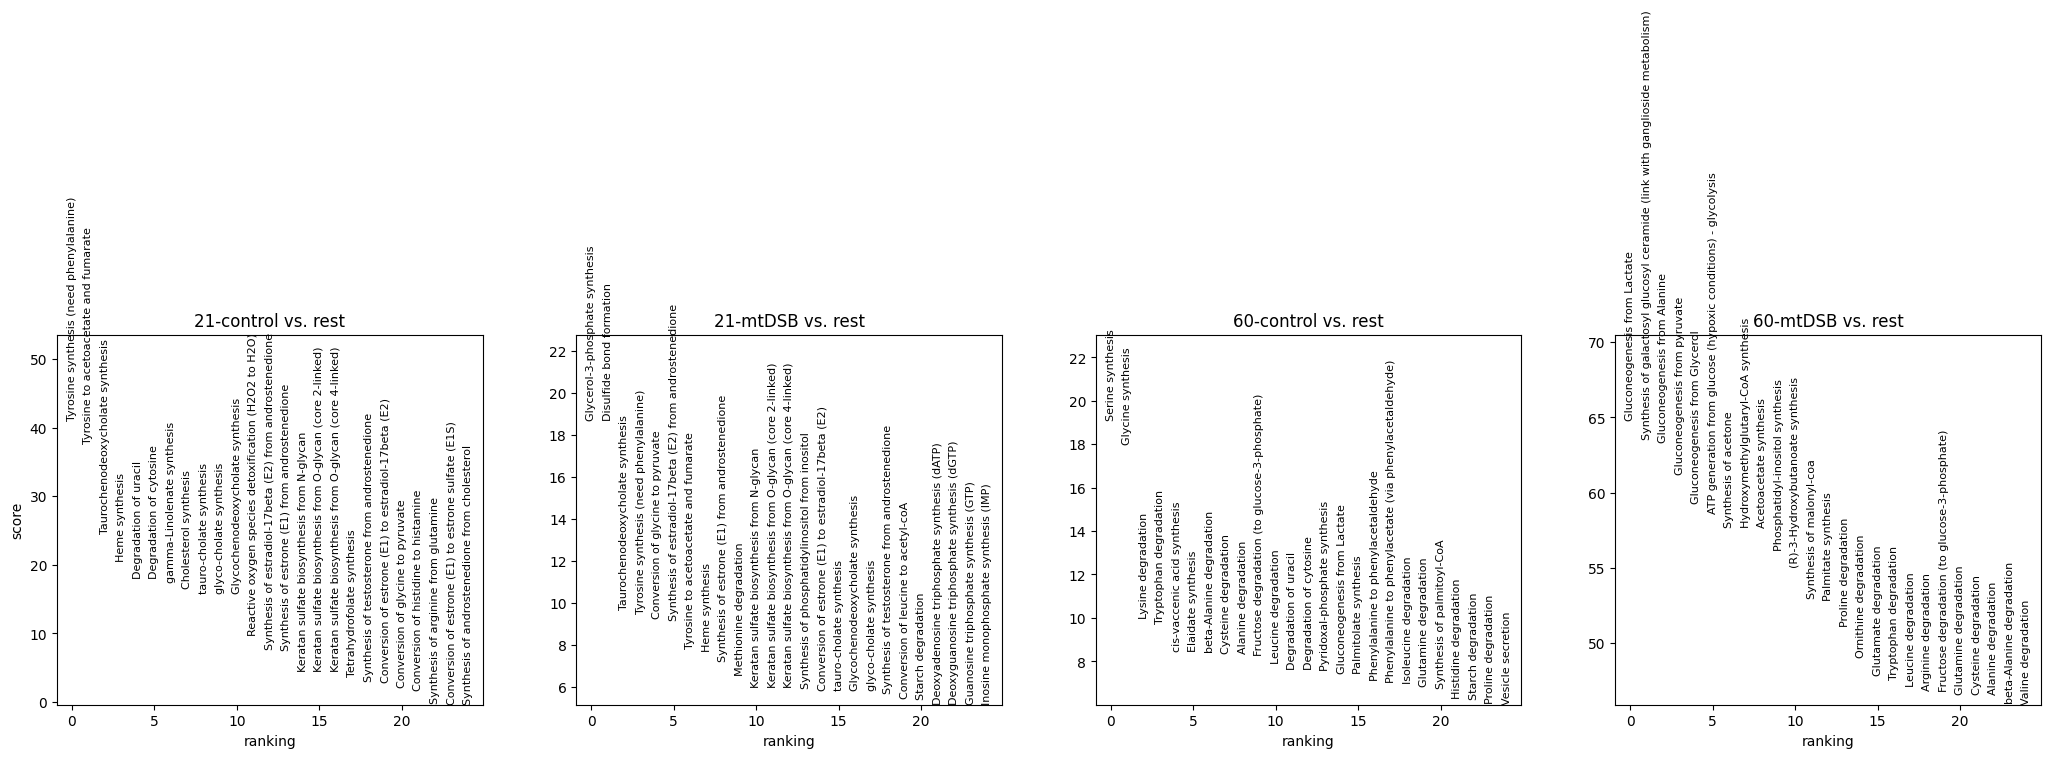

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,21-control,Tyrosine synthesis (need phenylalanine),41.048264,0.736106,0.000000e+00,0.000000e+00
1,21-control,Tyrosine to acetoacetate and fumarate,37.733974,0.727687,3.903164e-308,1.453928e-307
2,21-control,Taurochenodeoxycholate synthesis,24.561224,0.389510,1.348776e-132,3.464959e-132
3,21-control,Heme synthesis,20.575638,0.156861,8.567457e-94,1.994611e-93
4,21-control,Degradation of uracil,18.040707,0.261477,1.334528e-72,2.616378e-72


In [35]:
ad_met_OL = ad_met[ad_met.obs.cell_class == 'Oligodendrocytes']
# --- Find marker genes per cluster ---
sc.tl.rank_genes_groups(ad_met_OL, groupby="age-condition", method="t-test")
sc.pl.rank_genes_groups(ad_met_OL, n_genes=25, sharey=False)

# get a tidy table of top markers
markers = sc.get.rank_genes_groups_df(ad_met_OL, group=None)
markers.head()

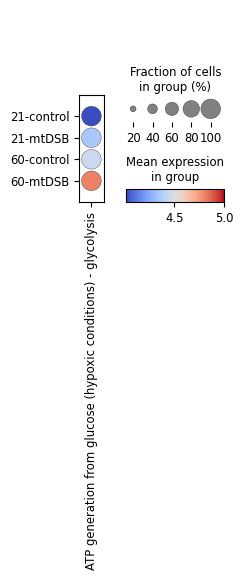

In [48]:
sc.pl.dotplot(
    ad_met_OL,
    var_names=['ATP generation from glucose (hypoxic conditions) - glycolysis'],#[i for i in ad_met_OL.var.index if "lactate" in i.lower()],
    groupby="age-condition",
    color_map="coolwarm",
     vmax = 5
)

/Users/christoffer/miniconda3/envs/sccellfie_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


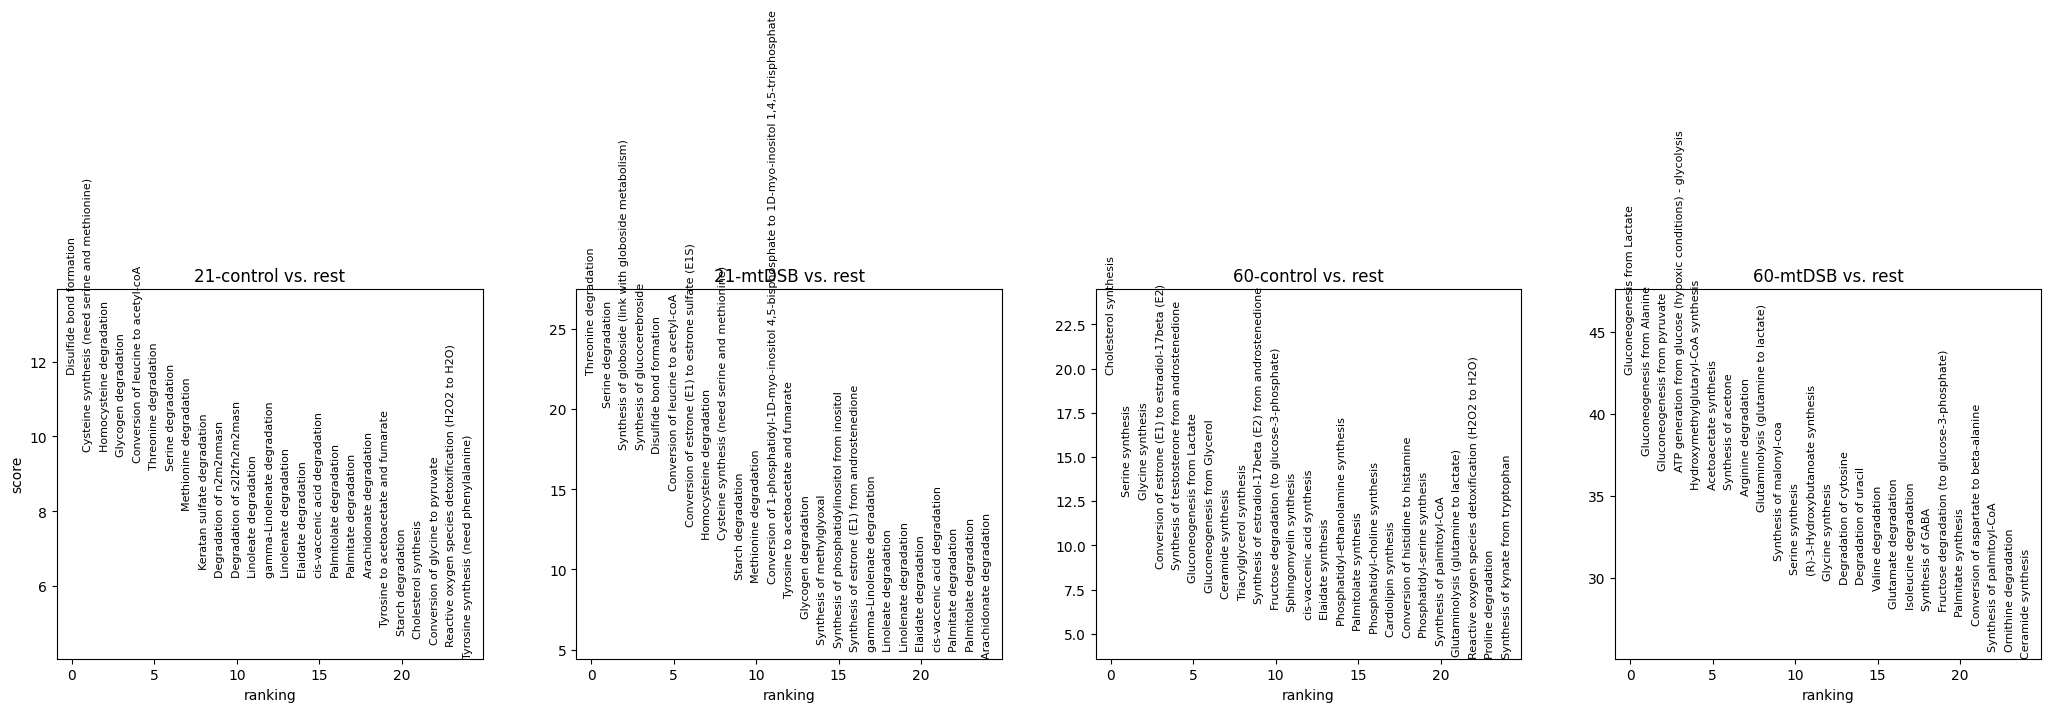

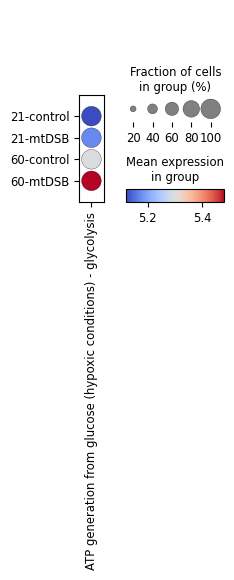

In [50]:
ad_met_AS = ad_met[ad_met.obs.cell_class == 'Astrocytes']
# --- Find marker genes per cluster ---
sc.tl.rank_genes_groups(ad_met_AS, groupby="age-condition", method="t-test")
sc.pl.rank_genes_groups(ad_met_AS, n_genes=25, sharey=False)

# get a tidy table of top markers
markers = sc.get.rank_genes_groups_df(ad_met_AS, group=None)
markers.head()
sc.pl.dotplot(
    ad_met_AS,
    var_names=['ATP generation from glucose (hypoxic conditions) - glycolysis'],#[i for i in ad_met_OL.var.index if "lactate" in i.lower()],
    groupby="age-condition",
    color_map="coolwarm",
)

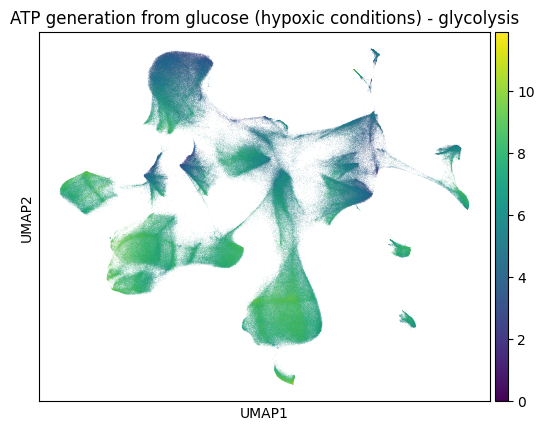

In [51]:
sc.pl.umap(ad_met, color = 'ATP generation from glucose (hypoxic conditions) - glycolysis')

/Users/christoffer/miniconda3/envs/sccellfie_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


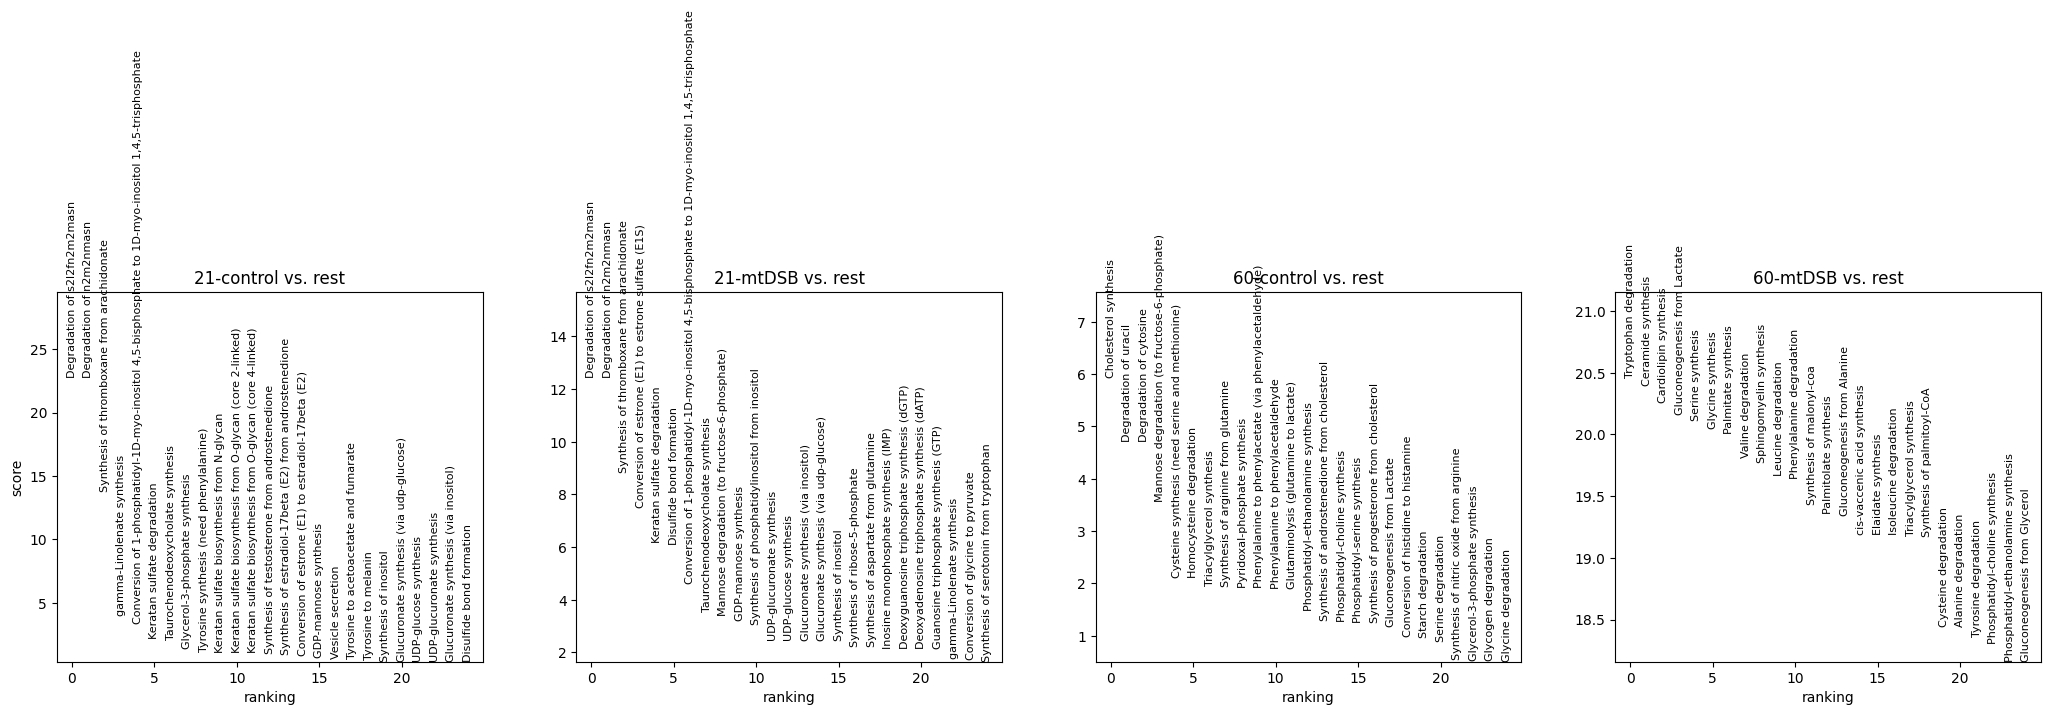

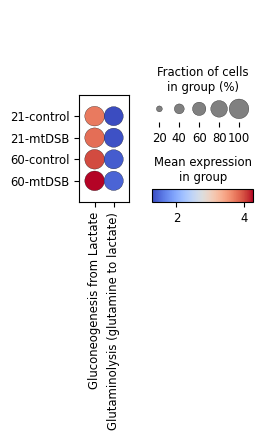

In [41]:
ad_met_MG = ad_met[ad_met.obs.cell_class == 'Microglia']
# --- Find marker genes per cluster ---
sc.tl.rank_genes_groups(ad_met_MG, groupby="age-condition", method="t-test")
sc.pl.rank_genes_groups(ad_met_MG, n_genes=25, sharey=False)

# get a tidy table of top markers
markers = sc.get.rank_genes_groups_df(ad_met_MG, group=None)
markers.head()
sc.pl.dotplot(
    ad_met_MG,
    var_names=[i for i in ad_met_OL.var.index if "lactate" in i.lower()],
    groupby="age-condition",
    color_map="coolwarm",
)

In [34]:
ad_met.write('')

AnnData object with n_obs × n_vars = 980474 × 149
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'n_genes_by_counts', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_2', 'cell_class', 'sample_id', 'age', 'sex', 'genotype', 'condition', 'cell_type', 'cell_id', 'rbd_domain_0.1', 'rbd_domain_0.2', 'rbd_domain_0.5', 'rbd_domain_1.0', 'RBD_compartment', 'RBD_compartment_simplified', 'leiden_1.5', 'leiden_2.1', 'leiden_2.3', 'leiden_2.5', 'leiden_3', 'age-condition'
    uns: 'normalization', 'neighbors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap', 'spatial'
    obsp: 'connectivities', 'distances'